# 双均线策略回测

本 Notebook 使用 MongoDB 行情构建单标的双均线策略，并对比大盘基准的净值、超额收益、回撤和核心绩效指标。

首版规则：短均线上穿长均线后持有，否则空仓；收盘信号从下一交易日生效；交易成本按仓位变化单边收取。

使用前安装项目并确认 MongoDB 已启动：

```bash
conda run -n quant pip install -e ".[notebook]"
```

运行时会优先读取本地行情；如果策略标的或基准在所选日期范围内没有数据，Notebook 会通过 AkShare 或 yfinance 自动下载并写入 MongoDB。A 股示例可将标的改为 `600519.SH`，基准改为沪深300 ETF `510300.SH`。

In [4]:
import math
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

from quant_backtest import (
    MovingAverageStrategy,
    PerformanceAnalyzer,
    SingleAssetBacktestEngine,
)
from quant_backtest.data import (
    AkShareProvider,
    MarketDataService,
    MongoMarketDataRepository,
    YFinanceProvider,
)

repository = MongoMarketDataRepository()
repository.ping()
data_service = MarketDataService(
    repository,
    {"CN": AkShareProvider(), "US": YFinanceProvider()},
)
print(f"数据库中共有 {len(repository.list_price_codes())} 个有行情的标的")

数据库中共有 11 个有行情的标的


## 参数

修改下列参数后，从本单元开始依次重新运行：

- `CODE`：策略标的
- `BENCHMARK_CODE`：同市场基准；美股建议 `SPY.US`，A 股建议 `510300.SH`
- `SHORT_WINDOW` / `LONG_WINDOW`：双均线窗口，短窗口必须小于长窗口
- `TRANSACTION_COST_BPS`：每次仓位变化的单边成本，单位为基点
- `RISK_FREE_RATE`：年化无风险利率
- `SAVE_PATH`：可选的综合图输出路径

In [5]:
# === 用户参数 ===
CODE = "AAPL.US"
BENCHMARK_CODE = "SPY.US"
START_DATE = "2018-01-01"
END_DATE = "2024-12-31"
SHORT_WINDOW = 20
LONG_WINDOW = 60
TRANSACTION_COST_BPS = 5.0
RISK_FREE_RATE = 0.0
SAVE_PATH = None  # 例如 "output/aapl_ma_backtest.png"

In [6]:
def load_prices(code, start, end):
    normalized_code = code.strip().upper()
    data = repository.read_prices(codes=[normalized_code], start=start, end=end)
    if not data.empty:
        return data

    market = (
        "CN"
        if normalized_code.endswith((".SH", ".SZ", ".BJ"))
        else "US"
    )
    print(f"本地缺少 {normalized_code} 行情，正在自动下载……")
    result = data_service.load(
        {market: [normalized_code]},
        start=start,
        end=end,
        incremental=False,
    )
    data = repository.read_prices(
        codes=[normalized_code], start=start, end=end
    )
    if data.empty:
        raise ValueError(
            f"无法取得 {normalized_code} 行情：{result.get(normalized_code)}"
        )
    print(f"{normalized_code} 已下载并写入 MongoDB")
    return data


prices = load_prices(CODE, START_DATE, END_DATE)
benchmark_prices = load_prices(BENCHMARK_CODE, START_DATE, END_DATE)
print(f"策略标的：{CODE}，{len(prices)} 条行情")
print(f"对照基准：{BENCHMARK_CODE}，{len(benchmark_prices)} 条行情")

策略标的：AAPL.US，1761 条行情
对照基准：SPY.US，1761 条行情


In [7]:
strategy = MovingAverageStrategy(
    short_window=SHORT_WINDOW,
    long_window=LONG_WINDOW,
)
signals = strategy.generate_signals(prices)
result = SingleAssetBacktestEngine(
    transaction_cost_bps=TRANSACTION_COST_BPS
).run(prices, signals)
strategy_daily = result.daily
strategy_daily.tail()

,date,code,adjusted_close,short_ma,long_ma,signal,position,asset_return,turnover,transaction_cost,gross_return,return,net_value,drawdown
1756,2024-12-24,AAPL.US,256.560822,244.729909,232.829204,1.0,1.0,0.011478,0.0,0.0,0.011478,0.011478,4.418681,0.000000
1757,2024-12-26,AAPL.US,257.375580,245.920302,233.376682,1.0,1.0,0.003176,0.0,0.0,0.003176,0.003176,4.432713,0.000000
1758,2024-12-27,AAPL.US,253.967392,246.946744,233.857927,1.0,1.0,-0.013242,0.0,0.0,-0.013242,-0.013242,4.374015,-0.013242
1759,2024-12-30,AAPL.US,250.598892,247.685523,234.301394,1.0,1.0,-0.013264,0.0,0.0,-0.013264,-0.013264,4.316000,-0.026330
1760,2024-12-31,AAPL.US,248.830215,248.223586,234.696689,1.0,1.0,-0.007058,0.0,0.0,-0.007058,-0.007058,4.285539,-0.033202


In [8]:
benchmark_daily = benchmark_prices.copy()
benchmark_daily["date"] = pd.to_datetime(benchmark_daily["date"]).dt.normalize()
benchmark_daily = benchmark_daily.sort_values("date").drop_duplicates("date", keep="last")
benchmark_daily["adjusted_close"] = (
    pd.to_numeric(benchmark_daily["close"]) * pd.to_numeric(benchmark_daily["adj_factor"])
)
benchmark_daily["benchmark_return"] = benchmark_daily["adjusted_close"].pct_change(fill_method=None).fillna(0.0)

comparison = strategy_daily[["date", "return"]].merge(
    benchmark_daily[["date", "benchmark_return"]], on="date", how="inner", validate="one_to_one"
)
if comparison.empty:
    raise ValueError("策略标的与基准没有重叠交易日，请选择同市场基准和有效日期范围")

comparison["strategy_net_value"] = (1.0 + comparison["return"]).cumprod()
comparison["benchmark_net_value"] = (1.0 + comparison["benchmark_return"]).cumprod()
comparison["excess_net_value"] = comparison["strategy_net_value"] / comparison["benchmark_net_value"]
comparison["strategy_drawdown"] = comparison["strategy_net_value"] / comparison["strategy_net_value"].cummax() - 1.0
comparison["benchmark_drawdown"] = comparison["benchmark_net_value"] / comparison["benchmark_net_value"].cummax() - 1.0

analyzer = PerformanceAnalyzer(risk_free_rate=RISK_FREE_RATE)
strategy_metrics = analyzer.analyze(comparison[["return"]])
benchmark_metrics = analyzer.analyze(
    comparison[["benchmark_return"]].rename(columns={"benchmark_return": "return"})
)
active_return = comparison["return"] - comparison["benchmark_return"]
tracking_error = active_return.std(ddof=1) * math.sqrt(252)
information_ratio = (
    active_return.mean() / active_return.std(ddof=1) * math.sqrt(252)
    if active_return.std(ddof=1) > 0
    else 0.0
)

In [9]:
metrics_table = pd.DataFrame(
    {
        "Strategy": {
            "Total Return": strategy_metrics["net_value"] - 1.0,
            "Annual Return": strategy_metrics["annual_return"],
            "Sharpe Ratio": strategy_metrics["sharpe_ratio"],
            "Max Drawdown": strategy_metrics["max_drawdown"],
        },
        "Benchmark": {
            "Total Return": benchmark_metrics["net_value"] - 1.0,
            "Annual Return": benchmark_metrics["annual_return"],
            "Sharpe Ratio": benchmark_metrics["sharpe_ratio"],
            "Max Drawdown": benchmark_metrics["max_drawdown"],
        },
    }
).T
relative_metrics = pd.Series(
    {
        "Cumulative Excess Return": comparison["excess_net_value"].iloc[-1] - 1.0,
        "Annual Excess Return": strategy_metrics["annual_return"] - benchmark_metrics["annual_return"],
        "Tracking Error": tracking_error,
        "Information Ratio": information_ratio,
    },
    name="Relative Performance",
)

display(metrics_table.style.format({
    "Total Return": "{:.2%}",
    "Annual Return": "{:.2%}",
    "Sharpe Ratio": "{:.3f}",
    "Max Drawdown": "{:.2%}",
}))
display(relative_metrics.to_frame().style.format("{:.3f}"))

,Total Return,Annual Return,Sharpe Ratio,Max Drawdown
Strategy,328.55%,23.15%,1.056,-21.16%
Benchmark,144.21%,13.63%,0.755,-33.72%


,Relative Performance
Cumulative Excess Return,0.755
Annual Excess Return,0.095
Tracking Error,0.213
Information Ratio,0.403


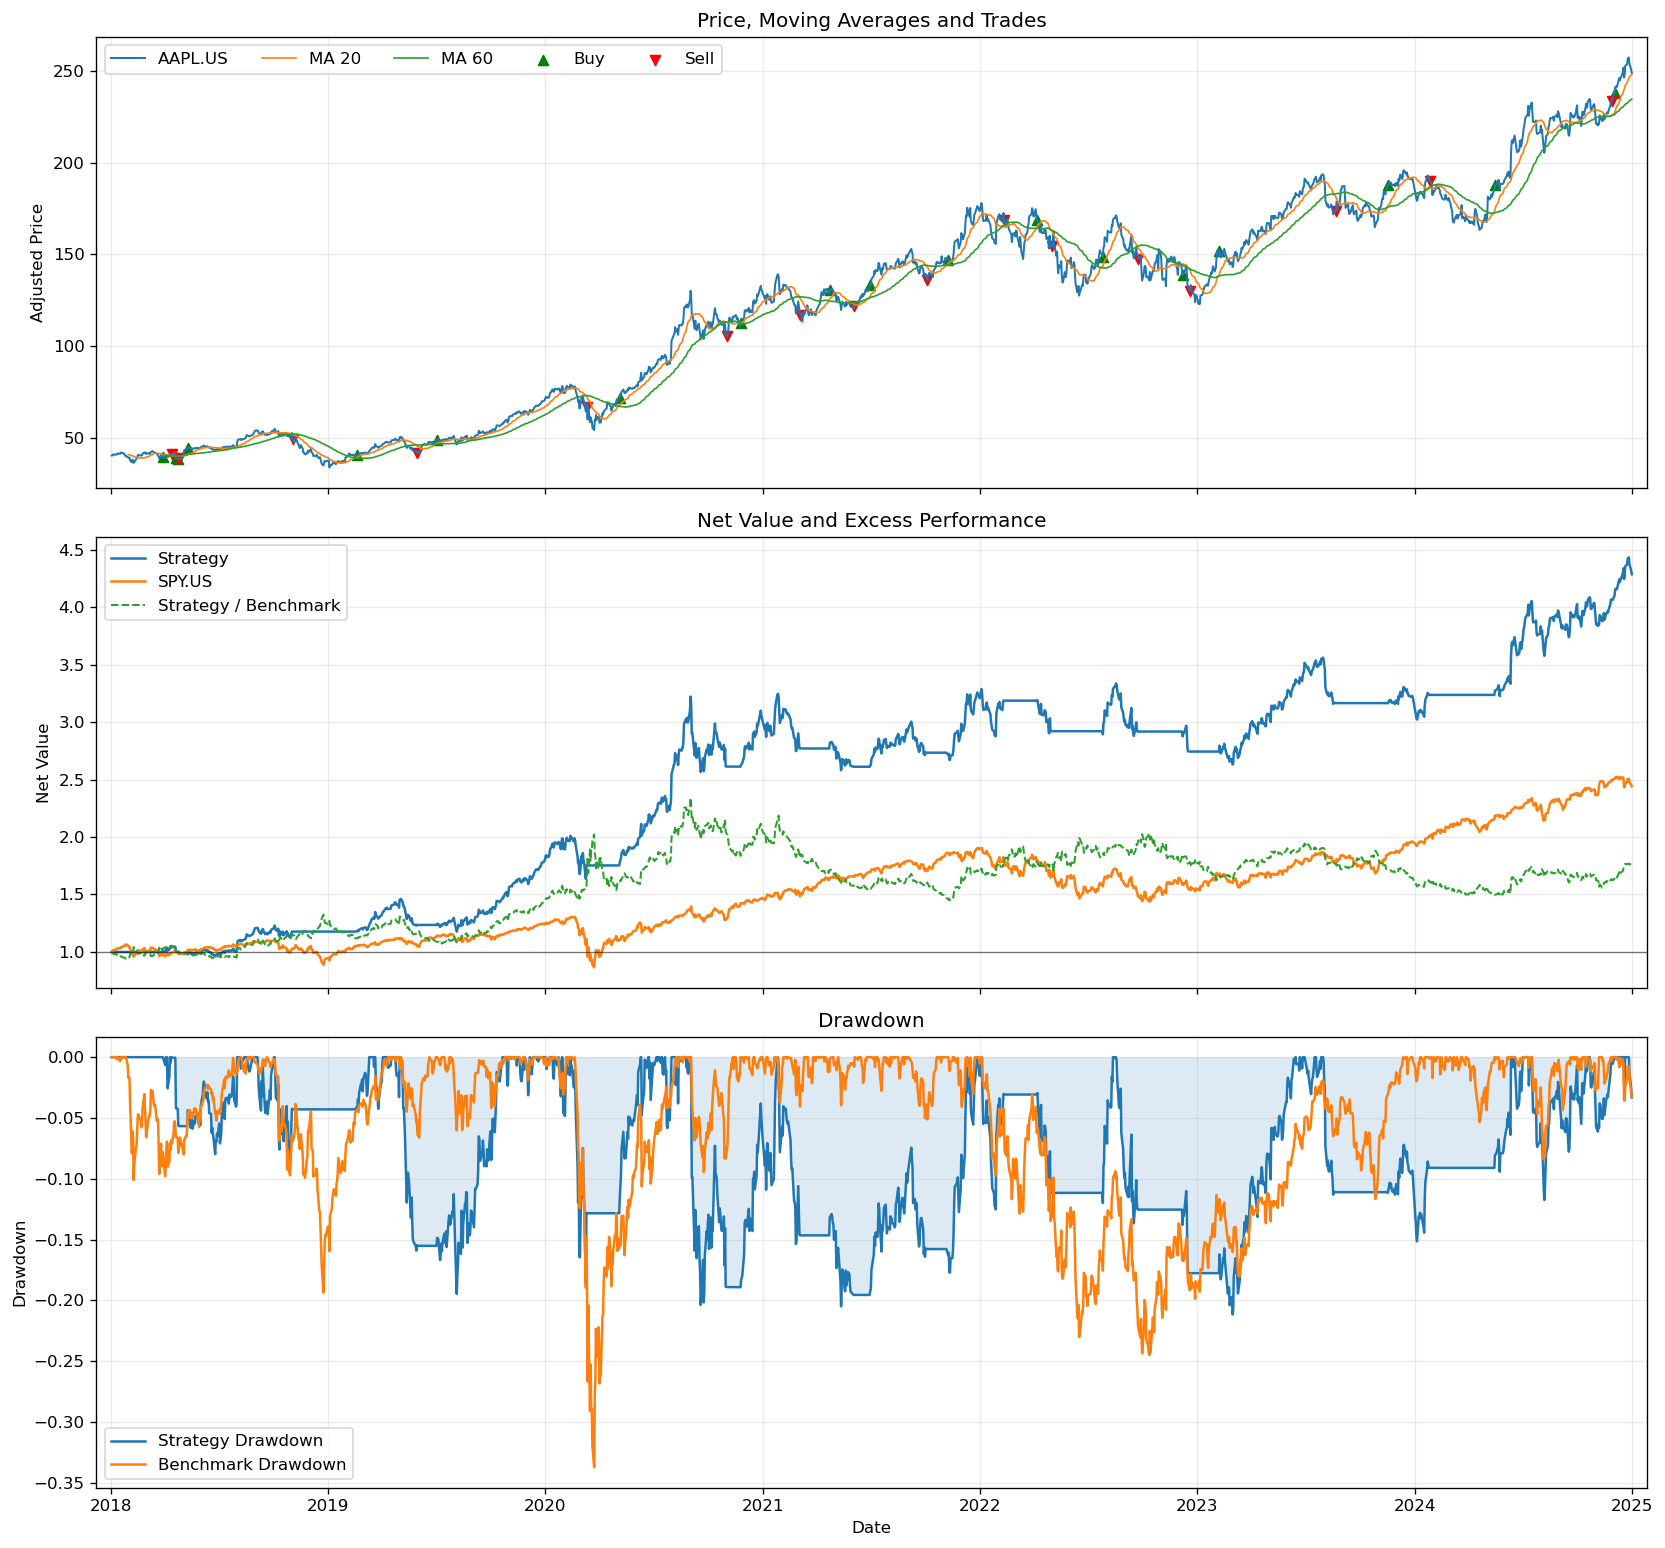

In [10]:
position_change = strategy_daily["position"].diff().fillna(strategy_daily["position"])
buy_points = strategy_daily[position_change > 0]
sell_points = strategy_daily[position_change < 0]

figure, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True, dpi=120)

axes[0].plot(strategy_daily["date"], strategy_daily["adjusted_close"], label=CODE, linewidth=1.2)
axes[0].plot(strategy_daily["date"], strategy_daily["short_ma"], label=f"MA {SHORT_WINDOW}", linewidth=1.0)
axes[0].plot(strategy_daily["date"], strategy_daily["long_ma"], label=f"MA {LONG_WINDOW}", linewidth=1.0)
axes[0].scatter(buy_points["date"], buy_points["adjusted_close"], marker="^", color="green", s=35, label="Buy")
axes[0].scatter(sell_points["date"], sell_points["adjusted_close"], marker="v", color="red", s=35, label="Sell")
axes[0].set_title("Price, Moving Averages and Trades")
axes[0].set_ylabel("Adjusted Price")
axes[0].legend(ncol=5)

axes[1].plot(comparison["date"], comparison["strategy_net_value"], label="Strategy", linewidth=1.5)
axes[1].plot(comparison["date"], comparison["benchmark_net_value"], label=BENCHMARK_CODE, linewidth=1.5)
axes[1].plot(comparison["date"], comparison["excess_net_value"], label="Strategy / Benchmark", linestyle="--", linewidth=1.2)
axes[1].axhline(1.0, color="black", linewidth=0.8, alpha=0.5)
axes[1].set_title("Net Value and Excess Performance")
axes[1].set_ylabel("Net Value")
axes[1].legend()

axes[2].plot(comparison["date"], comparison["strategy_drawdown"], label="Strategy Drawdown")
axes[2].plot(comparison["date"], comparison["benchmark_drawdown"], label="Benchmark Drawdown")
axes[2].fill_between(comparison["date"], comparison["strategy_drawdown"], 0, alpha=0.15)
axes[2].set_title("Drawdown")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Drawdown")
axes[2].legend()

locator = mdates.AutoDateLocator(minticks=5, maxticks=10)
axes[2].xaxis.set_major_locator(locator)
axes[2].xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
for axis in axes:
    axis.grid(True, alpha=0.25)
    axis.margins(x=0.01)

figure.tight_layout()
if SAVE_PATH:
    output = Path(SAVE_PATH).expanduser()
    output.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(output, dpi=160, bbox_inches="tight")
    print(f"图片已保存到：{output}")
plt.show()